Bibliotekos

In [1]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

Duomenų įsikėlimas

In [2]:
meteo_data = pd.read_csv("Matavimas.csv", sep = ',')
meteo_data.head(5)

C:\Users\eveli\AppData\Local\Temp\ipykernel_33072\2527246135.py:1: DtypeWarning: Columns (0: _page.next) have mixed types. Specify dtype option on import or set low_memory=False.
  meteo_data = pd.read_csv("Matavimas.csv", sep = ',')


,_type,_id,_revision,_page.next,vda_prime_key,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
0,datasets/gov/lhmt/stebejimai/Matavimas,1eff61d5-399f-4348-a676-1d0645f3cef1,082b0352-2ea8-467b-aea3-b3ba24fbc0d1,NaN,000001825dce7a2,Varėnos AMS,varenos-ams,24.551760,54.248271,2024-12-19T11:00:00,8.8,7.3,2.6,6.8,189.0,88.0,999.7,88.0,0.0,debesuota
1,datasets/gov/lhmt/stebejimai/Matavimas,6a1ade5a-7864-4c80-a012-6e5046e9353e,77a2819b-c0fa-4706-b543-62332bd5ed57,NaN,000002c87b99a6c,Utenos AMS,utenos-ams,25.589692,55.515321,2015-04-01T16:00:00,5.2,5.2,2.1,4.1,254.0,88.0,987.2,91.0,0.0,debesuota
2,datasets/gov/lhmt/stebejimai/Matavimas,584feb71-3f2b-4440-b2ca-64b9a8fd0a3f,f4453408-51c7-4d7a-b7b6-4af9f0b82b2d,NaN,00001d8a886c858,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2020-09-24T14:00:00,22.8,22.8,4.3,8.2,173.0,13.0,1008.9,49.0,0.0,mažai debesuota
3,datasets/gov/lhmt/stebejimai/Matavimas,3f8bbe2a-221d-49bf-8fbd-e91b2b25f51e,a1aa4732-0e09-4771-8e9f-4cf65e515fc3,NaN,00001e35fc20c59,Raseinių AMS,raseiniu-ams,23.133073,55.394569,2017-01-24T13:00:00,1.6,-1.9,3.4,5.8,291.0,88.0,1019.9,86.0,0.0,debesuota
4,datasets/gov/lhmt/stebejimai/Matavimas,f8788082-8986-4fa6-8b0d-577ac9dd795d,762c60b8-9ee2-498f-810e-8407a834e905,NaN,00001e87f6d2501,Dūkšto AMS,duksto-ams,26.316140,55.517856,2016-11-11T18:00:00,-3.1,-3.1,0.9,3.1,261.0,100.0,1019.4,92.0,0.0,trumpas sniegas


In [3]:
meteo_data_clean = meteo_data.drop(columns = ['_type', '_id', '_revision', '_page.next', 'vda_prime_key'])
meteo_data_clean['stebejimo_laikas'] = pd.to_datetime(meteo_data_clean['stebejimo_laikas'])
meteo_data_clean.head(5)

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
0,Varėnos AMS,varenos-ams,24.551760,54.248271,2024-12-19 11:00:00,8.8,7.3,2.6,6.8,189.0,88.0,999.7,88.0,0.0,debesuota
1,Utenos AMS,utenos-ams,25.589692,55.515321,2015-04-01 16:00:00,5.2,5.2,2.1,4.1,254.0,88.0,987.2,91.0,0.0,debesuota
2,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2020-09-24 14:00:00,22.8,22.8,4.3,8.2,173.0,13.0,1008.9,49.0,0.0,mažai debesuota
3,Raseinių AMS,raseiniu-ams,23.133073,55.394569,2017-01-24 13:00:00,1.6,-1.9,3.4,5.8,291.0,88.0,1019.9,86.0,0.0,debesuota
4,Dūkšto AMS,duksto-ams,26.316140,55.517856,2016-11-11 18:00:00,-3.1,-3.1,0.9,3.1,261.0,100.0,1019.4,92.0,0.0,trumpas sniegas


In [4]:
meteo_data_clean.shape

(2463879, 15)

Stočių pavadinimai

In [5]:
station_names = meteo_data_clean["stoties_pavadinimas"].unique()
station_names

<ArrowStringArray>
[     'Varėnos AMS',       'Utenos AMS',     'Vilniaus AMS',
     'Raseinių AMS',       'Dūkšto AMS',      'Šiaulių AMS',
  'Druskininkų AMS',     'Mažeikių AMS',      'Plungės AMS',
     'Rokiškio AMS',     'Vėžaičių AMS',      'Kybartų AMS',
   'Kalvarijos AMS',      'Pagėgių AMS',      'Lazdijų AMS',
     'Joniškio AMS',     'Ukmergės AMS',        'Biržų AMS',
     'Laukuvos AMS',    'Klaipėdos AMS',        'Nidos AMS',
        'Kauno AMS',      'Šilutės AMS',       'Zarasų AMS',
      'Rietavo AMS',       'Telšių AMS', 'Marijampolės AMS',
     'Pakruojo AMS',    'Panevėžio AMS',       'Kelmės AMS',
        'Šakių AMS',     'Dotnuvos AMS',       'Skuodo AMS',
      'Jonavos AMS',      'Alytaus AMS',      'Akmenės AMS',
     'Tauragės AMS',      'Šeduvos AMS',    'Kretingos AMS',
       'Molėtų AMS',    'Elektrėnų AMS',        'Trakų AMS',
   'Šalčininkų AMS',     'Anykščių AMS',     'Kupiškio AMS',
     'Birštono AMS',       'Prienų AMS',  'Kaišiadorių AMS',
     

Pirmos 10 stočių pagal stebėjimų skaičių

In [6]:
data_count_station = []
for station in station_names:
    data_count_station.append(len(meteo_data_clean[meteo_data_clean['stoties_pavadinimas'] == f'{station}']))
data_count_station_df = pd.DataFrame(data_count_station, index = station_names, columns=['skaicius'])
data_count_station_df.sort_values(by = 'skaicius', ascending = False)[:10]

,skaicius
Utenos AMS,112145
Dūkšto AMS,112143
Varėnos AMS,112142
Kybartų AMS,112136
Ukmergės AMS,112134
Šilutės AMS,112133
Kauno AMS,112132
Raseinių AMS,112131
Vilniaus AMS,112129
Biržų AMS,112124


Praleistos reikšmės visame rinkinyje

In [7]:
column_nan_count = meteo_data_clean.isnull().sum()
column_nan_count

stoties_pavadinimas         0
stoties_kodas               0
ilguma                      0
platuma                     0
stebejimo_laikas            0
oro_temp                  213
juntamoji_temp         356614
vejo_greitis           355728
vejo_gusis             355794
vejo_kryptis           357104
debesuotumas           502441
slegis_juros_lyg       381345
santyk_oro_dregme        7294
kritutliu_kiekis         2144
oro_salygos            470413
dtype: int64

Pirmos 10 stočių pagal mažiausią praleistų reikšmių skaičių

In [8]:
na_by_station = meteo_data_clean.groupby('stoties_pavadinimas').apply(lambda x: x.isnull().sum().sum())
na_by_station.sort_values(ascending = True)[:10]

stoties_pavadinimas
Utenos AMS       1405
Kybartų AMS      2058
Klaipėdos AMS    2151
Varėnos AMS      2891
Vilniaus AMS     2972
Šilutės AMS      3193
Kauno AMS        3197
Panevėžio AMS    3674
Nidos AMS        3862
Telšių AMS       4363
dtype: int64

#### Vilniaus stotis analizė

In [9]:
data_Vilnius = meteo_data_clean[meteo_data_clean['stoties_pavadinimas'] == 'Vilniaus AMS']
data_Vilnius.shape

(112129, 15)

Praleistos reikšmės pagal stulpelį

In [10]:
data_Vilnius.isnull().sum()

stoties_pavadinimas       0
stoties_kodas             0
ilguma                    0
platuma                   0
stebejimo_laikas          0
oro_temp                 30
juntamoji_temp           34
vejo_greitis             37
vejo_gusis               44
vejo_kryptis             74
debesuotumas           2226
slegis_juros_lyg         30
santyk_oro_dregme        40
kritutliu_kiekis         38
oro_salygos             419
dtype: int64

Min ir max laikas:

In [11]:
print(min(data_Vilnius["stebejimo_laikas"]))
print(max(data_Vilnius["stebejimo_laikas"]))

2013-04-10 00:00:00
2026-03-11 23:00:00


Praleistos reikšmės pagal metus kiekvienam stulpeliui

In [12]:
station_year = data_Vilnius["stebejimo_laikas"].dt.year.unique()
station_year.sort()
nan_year_result = []
for year in station_year:
    nan_year_result.append(data_Vilnius[data_Vilnius["stebejimo_laikas"].dt.year == year].isnull().sum())
nan_year_Vilnius = pd.DataFrame(nan_year_result, index = station_year)
nan_year_Vilnius

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
2013,0,0,0,0,0,2,2,1,1,1,101,0,2,0,1
2014,0,0,0,0,0,0,0,0,0,40,187,0,0,4,32
2015,0,0,0,0,0,0,0,0,0,0,202,0,2,0,36
2016,0,0,0,0,0,1,1,1,1,1,138,0,1,1,1
2017,0,0,0,0,0,0,0,0,0,0,112,0,0,0,21
2018,0,0,0,0,0,0,0,2,3,0,173,1,0,1,19
2019,0,0,0,0,0,0,0,1,0,0,130,0,0,6,1
2020,0,0,0,0,0,16,16,18,15,18,306,16,17,0,151
2021,0,0,0,0,0,0,0,0,0,0,149,0,0,0,35
2022,0,0,0,0,0,0,0,0,0,0,270,0,0,0,99


#### Galutinės aibės paruošimas

In [13]:
meteo_Vilnius = data_Vilnius[(data_Vilnius["stebejimo_laikas"].dt.date >= datetime.date(2017,11,1)) & (data_Vilnius["stebejimo_laikas"].dt.date <= datetime.date(2026,3,1))].sort_values(by='stebejimo_laikas')
meteo_Vilnius.shape

(71909, 15)

In [14]:
meteo_Vilnius.head(5)

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
1577877,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2017-11-01 00:00:00,0.7,-2.5,2.8,4.9,312.0,88.0,1012.1,90.0,0.0,debesuota
854505,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2017-11-01 01:00:00,0.4,0.4,0.8,2.5,309.0,88.0,1012.4,91.0,0.0,debesuota
965038,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2017-11-01 02:00:00,0.8,0.8,1.0,2.7,247.0,100.0,1012.4,91.0,0.0,debesuota
2111098,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2017-11-01 03:00:00,0.7,0.7,1.3,2.9,259.0,88.0,1012.3,92.0,0.0,debesuota
129024,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2017-11-01 04:00:00,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,debesuota


In [15]:
meteo_Vilnius.tail(5)

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
1900595,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2026-03-01 19:00:00,1.8,-2.5,4.7,9.1,285.0,100.0,1021.9,83.0,0.0,debesuota
2371248,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2026-03-01 20:00:00,1.8,-2.6,4.9,9.3,275.0,100.0,1022.0,78.0,0.0,debesuota
2248742,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2026-03-01 21:00:00,1.8,-1.8,3.6,8.7,284.0,100.0,1022.1,77.0,0.0,debesuota
1077900,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2026-03-01 22:00:00,1.7,-1.4,2.9,7.6,266.0,100.0,1022.0,79.0,0.0,debesuota
854139,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2026-03-01 23:00:00,1.7,-1.7,3.3,6.3,254.0,88.0,1021.8,81.0,0.0,debesuota


Aibės praleistos reikšmės

In [16]:
meteo_Vilnius.isnull().sum()

stoties_pavadinimas       0
stoties_kodas             0
ilguma                    0
platuma                   0
stebejimo_laikas          0
oro_temp                 27
juntamoji_temp           31
vejo_greitis             35
vejo_gusis               42
vejo_kryptis             32
debesuotumas           1509
slegis_juros_lyg         30
santyk_oro_dregme        35
kritutliu_kiekis         33
oro_salygos             334
dtype: int64

Agregavimas naudojant vidurkį, modą, didžiausią reikšmę ir sumą

In [17]:
agg_logic = {
    'oro_temp': 'mean',
    'juntamoji_temp': 'mean',
    'vejo_greitis': 'mean',
    'vejo_gusis': 'max',
    'vejo_kryptis': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'debesuotumas': 'mean',
    'slegis_juros_lyg': 'mean',
    'santyk_oro_dregme': 'mean',
    'kritutliu_kiekis': 'sum',
    'oro_salygos': lambda x: x.mode().iloc[0] if not x.mode().empty else None
}

agg_meteo_Vilnius = meteo_Vilnius.groupby(meteo_Vilnius["stebejimo_laikas"].dt.date).agg(agg_logic)
agg_meteo_Vilnius = agg_meteo_Vilnius.reset_index()
agg_meteo_Vilnius["stebejimo_laikas"] = pd.to_datetime(agg_meteo_Vilnius["stebejimo_laikas"])
agg_meteo_Vilnius

,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
0,2017-11-01,4.441667,3.737500,2.820833,8.6,252.0,96.500000,1007.975000,94.125000,7.5,nedidelis lietus
1,2017-11-02,8.387500,8.387500,2.825000,7.7,242.0,94.000000,1000.504167,95.500000,12.2,nedidelis lietus
2,2017-11-03,7.116667,7.116667,2.454167,6.7,38.0,95.500000,1010.212500,94.541667,1.1,lietus
3,2017-11-04,6.275000,6.025000,2.812500,6.4,210.0,95.000000,1017.562500,93.083333,0.0,debesuota
4,2017-11-05,6.037500,4.833333,3.891667,8.7,159.0,71.708333,1015.170833,87.583333,0.0,debesuota
...,...,...,...,...,...,...,...,...,...,...,...
2992,2026-02-25,-1.991667,-4.641667,2.229167,9.2,315.0,99.000000,1022.991667,84.791667,0.3,debesuota
2993,2026-02-26,-2.100000,-5.512500,3.191667,8.5,164.0,69.416667,1029.512500,77.541667,0.0,debesuota
2994,2026-02-27,0.250000,-3.962500,4.008333,9.4,179.0,70.000000,1023.262500,76.000000,0.0,debesuota
2995,2026-02-28,3.491667,0.883333,2.766667,5.3,161.0,15.208333,1021.162500,76.083333,0.0,giedra


In [18]:
agg_meteo_Vilnius.isnull().sum()

stebejimo_laikas     0
oro_temp             0
juntamoji_temp       0
vejo_greitis         0
vejo_gusis           0
vejo_kryptis         0
debesuotumas         9
slegis_juros_lyg     0
santyk_oro_dregme    0
kritutliu_kiekis     0
oro_salygos          8
dtype: int64

In [19]:
agg_meteo_Vilnius.to_csv('Vilnius_meteo_data_2017_2026.csv', index=False, encoding='utf-8-sig')

#### Išsskirčių ir klaidų paieška

In [20]:
def outlier_fun(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound1 = Q1 - 1.5 * IQR
    upper_bound1 = Q3 + 1.5 * IQR
    outliers_count1 = ((data < lower_bound1) | (data > upper_bound1)).sum()

    lower_bound2 = Q1 - 3 * IQR
    upper_bound2 = Q3 + 3 * IQR
    outliers_count2 = ((data < lower_bound2) | (data > upper_bound2)).sum()

    outlier = pd.Series({
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Conditional_outliers': outliers_count1,
        'Outliers': outliers_count2
    })
    return outlier

In [21]:
def print_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    return(data[(data[column] < q1 - 3 * iqr) | (data[column] > q3 + 3 * iqr)])

In [22]:
outliers = agg_meteo_Vilnius.select_dtypes(include='number').apply(outlier_fun).T
outliers

,Q1,Q3,IQR,Conditional_outliers,Outliers
oro_temp,1.0292,15.7333,14.7042,0.0,0.0
juntamoji_temp,-2.1458,15.7208,17.8667,0.0,0.0
vejo_greitis,1.9000,3.5875,1.6875,33.0,0.0
vejo_gusis,6.7000,10.5000,3.8000,60.0,1.0
vejo_kryptis,125.0000,261.0000,136.0000,0.0,0.0
debesuotumas,41.3750,93.5000,52.1250,0.0,0.0
slegis_juros_lyg,1009.9167,1021.2542,11.3375,70.0,1.0
santyk_oro_dregme,68.1250,89.9583,21.8333,5.0,0.0
kritutliu_kiekis,0.0000,1.6000,1.6000,401.0,235.0


In [23]:
print_outliers(agg_meteo_Vilnius, 'vejo_gusis')

,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
1535,2022-01-14,3.495833,-1.433333,8.233333,22.7,309.0,93.916667,1003.1875,72.125,0.7,debesuota


In [24]:
print_outliers(agg_meteo_Vilnius, 'slegis_juros_lyg')

,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
2242,2023-12-22,1.420833,-3.05,4.9,13.2,196.0,93.416667,973.229167,89.25,2.4,debesuota


Išskirtys pagal metus

In [25]:
pd.set_option('display.width', 1000)
for year in agg_meteo_Vilnius["stebejimo_laikas"].dt.year.unique():
    print(f"\n-----{year}-----")
    outliers = agg_meteo_Vilnius[agg_meteo_Vilnius["stebejimo_laikas"].dt.year == year].select_dtypes(include='number').apply(outlier_fun).T
    print(outliers)


-----2017-----
                          Q1         Q3      IQR  Conditional_outliers  Outliers
oro_temp              0.0958     3.4250   3.3292                   0.0       0.0
juntamoji_temp       -3.2250     0.6167   3.8417                   2.0       0.0
vejo_greitis          2.5542     4.1833   1.6292                   0.0       0.0
vejo_gusis            6.7000    10.5000   3.8000                   0.0       0.0
vejo_kryptis        148.0000   210.0000  62.0000                   8.0       0.0
debesuotumas         83.6667    96.5714  12.9048                   4.0       0.0
slegis_juros_lyg   1003.8542  1017.0083  13.1542                   0.0       0.0
santyk_oro_dregme    89.5000    93.4167   3.9167                   4.0       1.0
kritutliu_kiekis      0.0000     1.8000   1.8000                  13.0       6.0

-----2018-----
                          Q1         Q3       IQR  Conditional_outliers  Outliers
oro_temp             -0.5458    17.3708   17.9167                   0.0     

#### Skaitinės charakteristikos

In [26]:
agg_meteo_Vilnius.select_dtypes(include='number').describe()

,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis
count,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2988.000000,2997.000000,2997.000000,2997.000000
mean,7.915927,6.495725,2.806641,8.819219,180.896897,64.260376,1015.333483,77.927513,1.725125
std,8.901783,10.374232,1.195565,2.918988,93.426290,31.758071,9.348015,14.461608,4.319764
min,-20.766667,-23.783333,0.237500,2.300000,0.000000,0.000000,973.229167,29.125000,0.000000
25%,1.029167,-2.145833,1.900000,6.700000,125.000000,41.375000,1009.916667,68.125000,0.000000
50%,7.520833,7.112500,2.645833,8.500000,176.000000,72.125000,1015.579167,80.583333,0.000000
75%,15.733333,15.720833,3.587500,10.500000,261.000000,93.500000,1021.254167,89.958333,1.600000
max,27.720833,28.795833,8.233333,22.700000,358.000000,100.000000,1048.041667,100.000000,78.400000


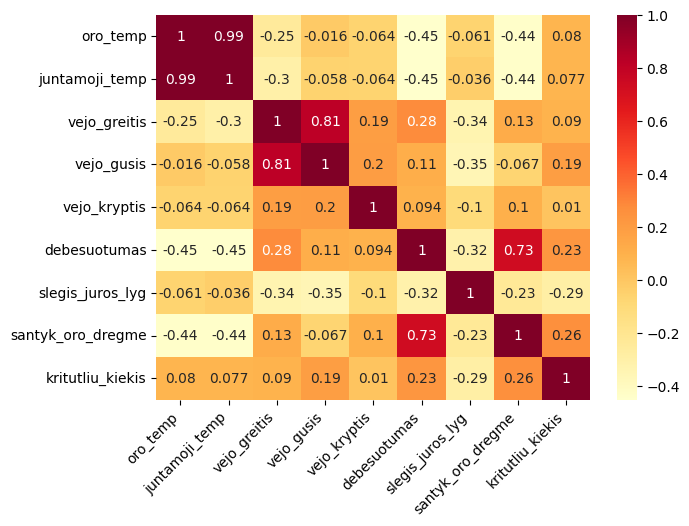

In [27]:
plt.figure(figsize=(7, 5))
ax = sns.heatmap(agg_meteo_Vilnius.select_dtypes(include='number').corr(), annot=True, cmap='YlOrRd')
plt.xticks(rotation=45, ha='right')
plt.show()